✈️ Flight Fare Prediction Using Machine Learning
1. Introduction

Flight ticket prices vary frequently due to multiple factors such as airline, journey date, route, duration, and number of stops. Predicting flight fares in advance helps customers plan better and assists airlines in pricing strategies.

2.Objectives
🔹 Task 1 – Exploratory Data Analysis (EDA)

Understand dataset structure

Handle missing values

Extract meaningful features

Visualize price patterns

🔹 Task 2 – Predictive Modeling

Train multiple ML models

Compare performance

Select the best model for deployment

# Problem Statement

Flight ticket prices change frequently and are difficult for customers to predict.
This project aims to:

Analyze factors affecting flight prices

Build predictive models

Help customers plan journeys efficiently

Assist airlines in pricing strategy

 # Import Required Libraries

In [374]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pickle
         

# Load Dataset

In [375]:
ff_data = pd.read_excel(r"C:\Users\ADMIN\Downloads\Project data sets\python\.venv\projects\mini projects\Flight_Fare.xlsx")

3. Dataset Description

The dataset contains flight information including airline, source, destination, journey date, duration, number of stops, additional information, and ticket price.


In [376]:
ff_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


# Features used:

Airline

Date_of_Journey

Source

Destination

Route

Arrival_Time

Duration

Total_Stops

Additional_Info

Price (Target)

In [377]:
ff_data.shape

(10683, 11)

In [378]:
ff_data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

4. Data Preprocessing

Removed duplicate rows

Handled missing values by dropping negligible rows

Converted date into day and month

Converted duration into total minutes

Extracted departure and arrival time features

Encoded categorical variables

Removed high-cardinality Route feature

In [379]:
ff_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [380]:
ff_data.dropna(subset=["Route", "Total_Stops"], how="all", inplace=True)        


In [381]:
ff_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [382]:
ff_data.drop("Route", axis=1, inplace=True)


In [383]:
ff_data.duplicated().sum()


np.int64(220)

In [384]:
duplicate_rows = ff_data[ff_data.duplicated()]

duplicate_rows


,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


In [385]:
duplicate_rows.shape

(220, 10)

# Remove duplicates

In [386]:
print("Before duplicating :", ff_data.shape)
ff_data.drop_duplicates(inplace=True)
print("After duplicating:", ff_data.shape)


Before duplicating : (10682, 10)
After duplicating: (10462, 10)


# Basic Dataset Information

In [387]:
ff_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Dep_Time         10462 non-null  object
 5   Arrival_Time     10462 non-null  object
 6   Duration         10462 non-null  object
 7   Total_Stops      10462 non-null  object
 8   Additional_Info  10462 non-null  object
 9   Price            10462 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 899.1+ KB


# Data Cleaning & Feature Engineering

➤ Handling Date_of_Journey

In [388]:
ff_data["Journey_day"] = pd.to_datetime(ff_data["Date_of_Journey"]).dt.day
ff_data["Journey_month"] = pd.to_datetime(ff_data["Date_of_Journey"]).dt.month
ff_data.drop("Date_of_Journey", axis=1,inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1259228465.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ff_data["Journey_day"] = pd.to_datetime(ff_data["Date_of_Journey"]).dt.day
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1259228465.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ff_data["Journey_month"] = pd.to_datetime(ff_data["Date_of_Journey"]).dt.month


In [389]:
ff_data["Duration"].head(10)


0     2h 50m
1     7h 25m
2        19h
3     5h 25m
4     4h 45m
5     2h 25m
6    15h 30m
7     21h 5m
8    25h 30m
9     7h 50m
Name: Duration, dtype: object

➤ Handling Duration

In [390]:
def convert_duration(duration):
    hours = 0
    minutes = 0
    
    if 'h' in duration:
        hours = int(duration.split('h')[0])
        duration = duration.split('h')[1]
        
    if 'm' in duration:
        minutes = int(duration.replace('m','').strip())
        
    return hours * 60 + minutes


In [391]:
ff_data["Duration"] = ff_data["Duration"].apply(convert_duration)


In [392]:
ff_data["Duration"].head()


0     170
1     445
2    1140
3     325
4     285
Name: Duration, dtype: int64

# ➤ Handling Arrival & Departure Time

In [393]:
ff_data["Arrival_hour"] = pd.to_datetime(ff_data["Arrival_Time"]).dt.hour
ff_data["Arrival_min"] = pd.to_datetime(ff_data["Arrival_Time"]).dt.minute
ff_data.drop("Arrival_Time", axis=1, inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1750754072.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ff_data["Arrival_hour"] = pd.to_datetime(ff_data["Arrival_Time"]).dt.hour
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1750754072.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ff_data["Arrival_min"] = pd.to_datetime(ff_data["Arrival_Time"]).dt.minute


In [394]:
ff_data["Dep_hour"] = pd.to_datetime(ff_data["Dep_Time"]).dt.hour
ff_data["Dep_min"] = pd.to_datetime(ff_data["Dep_Time"]).dt.minute
ff_data.drop("Dep_Time", axis=1, inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1027801106.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ff_data["Dep_hour"] = pd.to_datetime(ff_data["Dep_Time"]).dt.hour
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\1027801106.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ff_data["Dep_min"] = pd.to_datetime(ff_data["Dep_Time"]).dt.minute


➤ Handling Total Stops

In [395]:
ff_data["Total_Stops"] = ff_data["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3388\3463101055.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ff_data["Total_Stops"] = ff_data["Total_Stops"].replace({


# Handling Categorical Variables

In [396]:
le = LabelEncoder()      # label encoding

In [397]:
for col in ["Airline", "Source", "Destination", "Additional_Info"]:
    ff_data[col] = le.fit_transform(ff_data[col])

In [398]:
ff_data

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Arrival_hour,Arrival_min,Dep_hour,Dep_min
0,3,0,5,170,0,8,3897,24,3,1,10,22,20
1,1,3,0,445,2,8,7662,1,5,13,15,5,50
2,4,2,1,1140,2,8,13882,9,6,4,25,9,25
3,3,3,0,325,1,8,6218,12,5,23,30,18,5
4,3,0,5,285,1,8,13302,1,3,21,35,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,150,0,8,4107,9,4,22,25,19,55
10679,1,3,0,155,0,8,4145,27,4,23,20,20,45
10680,4,0,2,180,0,8,7229,27,4,11,20,8,20
10681,10,0,5,160,0,8,12648,1,3,14,10,11,30


In [399]:
ff_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10462 non-null  int64
 1   Source           10462 non-null  int64
 2   Destination      10462 non-null  int64
 3   Duration         10462 non-null  int64
 4   Total_Stops      10462 non-null  int64
 5   Additional_Info  10462 non-null  int64
 6   Price            10462 non-null  int64
 7   Journey_day      10462 non-null  int32
 8   Journey_month    10462 non-null  int32
 9   Arrival_hour     10462 non-null  int32
 10  Arrival_min      10462 non-null  int32
 11  Dep_hour         10462 non-null  int32
 12  Dep_min          10462 non-null  int32
dtypes: int32(6), int64(7)
memory usage: 899.1 KB


# 5. Exploratory Data Analysis

EDA showed that:

Prices increase with number of stops

Longer duration flights are more expensive

Airline type significantly affects price

➤ Airline vs Price

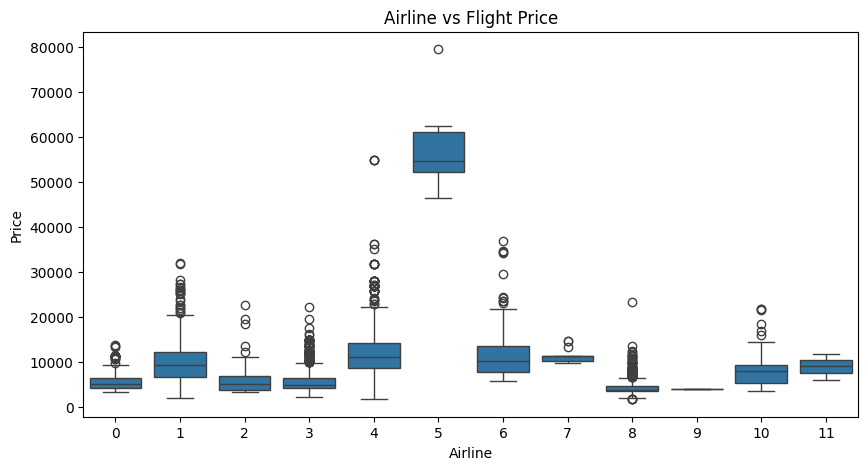

In [400]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Airline", y="Price", data=ff_data)
plt.title("Airline vs Flight Price")
plt.show()

➤ Total Stops vs Price

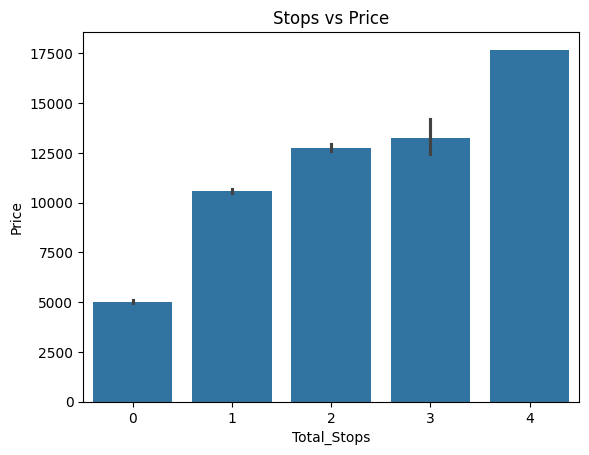

In [401]:
sns.barplot(x="Total_Stops", y="Price", data=ff_data)
plt.title("Stops vs Price")
plt.show()


# Train-Test Split

In [402]:
X = ff_data.drop("Price", axis=1)
y = ff_data["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


 # 6. Model Building & Evalution

🔹 1. Linear Regression


In [403]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [404]:


y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression R2: 0.44495768657539303


🔹 2. Decision Tree Regressor

In [405]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [406]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.8255183674927875


🔹 3. Random Forest Regressor 

In [407]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [408]:
y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.8853429164124842
MAE: 697.6125937290797
RMSE: 1546.1668349452448


In [409]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [410]:
y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))

Ridge Regression R2: 0.4449623171908179


In [411]:

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)


,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [412]:
y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))

Lasso Regression R2: 0.4449576914402755


In [413]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [414]:
y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gbr))

Gradient Boosting R2: 0.8054063255049733


In [415]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [416]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


XGBoost R2: 0.8950859308242798
MAE: 757.9750366210938
RMSE: 1479.015381934887


In [417]:


lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 8369, number of used features: 12
[LightGBM] [Info] Start training from score 9051.693512


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [418]:
y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM R2:", r2_score(y_test, y_pred_lgbm))
print("MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgbm)))


LightGBM R2: 0.8910312867196422
MAE: 792.2300106078674
RMSE: 1507.3247123431854


7. Model Evaluation

Random Forest, XGBoost, and LightGBM performed best. Linear models performed poorly, indicating non-linear relationships in the data.

In [419]:
models = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm
}

for model, pred in models.items():
    print(model, "R2:", r2_score(y_test, pred))


Linear Regression R2: 0.44495768657539303
Ridge Regression R2: 0.4449623171908179
Lasso Regression R2: 0.4449576914402755
Decision Tree R2: 0.8255183674927875
Random Forest R2: 0.8853429164124842
Gradient Boosting R2: 0.8054063255049733
XGBoost R2: 0.8950859308242798
LightGBM R2: 0.8910312867196422


8. Hyperparameter Tuning

RandomizedSearchCV was used to tune Random Forest parameters to improve performance and reduce overfitting.

In [420]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [421]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [422]:
print("Best RF Parameters:", rf_search.best_params_)
print("Best RF R2:", rf_search.best_score_)


Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best RF R2: 0.8801376808225323


In [423]:
best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned RF Test R2:", r2_score(y_test, y_pred_rf_tuned))


Tuned RF Test R2: 0.8808454395595499


In [424]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid_xgb = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}


In [425]:
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid_xgb,
    n_iter=15,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB R2:", xgb_search.best_score_)


Best XGB Params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best XGB R2: 0.8948908567428588


In [426]:
best_xgb = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Tuned XGB Test R2:", r2_score(y_test, y_pred_xgb_tuned))


Tuned XGB Test R2: 0.8905637264251709


In [427]:
lgbm = LGBMRegressor(random_state=42)

param_grid_lgbm = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8]
}


In [428]:
lgbm_search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=15,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print("Best LGBM Params:", lgbm_search.best_params_)
print("Best LGBM R2:", lgbm_search.best_score_)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 8369, number of used features: 12
[LightGBM] [Info] Start training from score 9051.693512
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [429]:
print("RF Original:", r2_score(y_test, y_pred_rf))
print("RF Tuned:", r2_score(y_test, y_pred_rf_tuned))


RF Original: 0.8853429164124842
RF Tuned: 0.8808454395595499


In [430]:
model_results = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Ridge Regression": r2_score(y_test, y_pred_ridge),
    "Lasso Regression": r2_score(y_test, y_pred_lasso),
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Gradient Boosting": r2_score(y_test, y_pred_gbr),
    "Random Forest": r2_score(y_test, y_pred_rf),
    "XGBoost": r2_score(y_test, y_pred_xgb),
    "LightGBM": r2_score(y_test, y_pred_lgbm)
}


In [431]:
for model, score in model_results.items():
    print(f"{model}: {score:.4f}")


Linear Regression: 0.4450
Ridge Regression: 0.4450
Lasso Regression: 0.4450
Decision Tree: 0.8255
Gradient Boosting: 0.8054
Random Forest: 0.8853
XGBoost: 0.8951
LightGBM: 0.8910


# Model Comparison Table (R², MAE, RMSE)

In [432]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Gradient Boosting",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_gbr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgbm)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_gbr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_gbr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ]
})


In [433]:
model_comparison = model_comparison.sort_values(by="R2 Score", ascending=False)
model_comparison


,Model,R2 Score,MAE,RMSE
6,XGBoost,0.895086,757.975037,1479.015382
7,LightGBM,0.891031,792.230011,1507.324712
5,Random Forest,0.885343,697.612594,1546.166835
3,Decision Tree,0.825518,804.101210,1907.351635
4,Gradient Boosting,0.805406,1266.051489,2014.281980
1,Ridge Regression,0.444962,2451.361424,3401.865530
2,Lasso Regression,0.444958,2451.391731,3401.879706
0,Linear Regression,0.444958,2451.391873,3401.879721


# Bar Chart Comparison (R² Score)

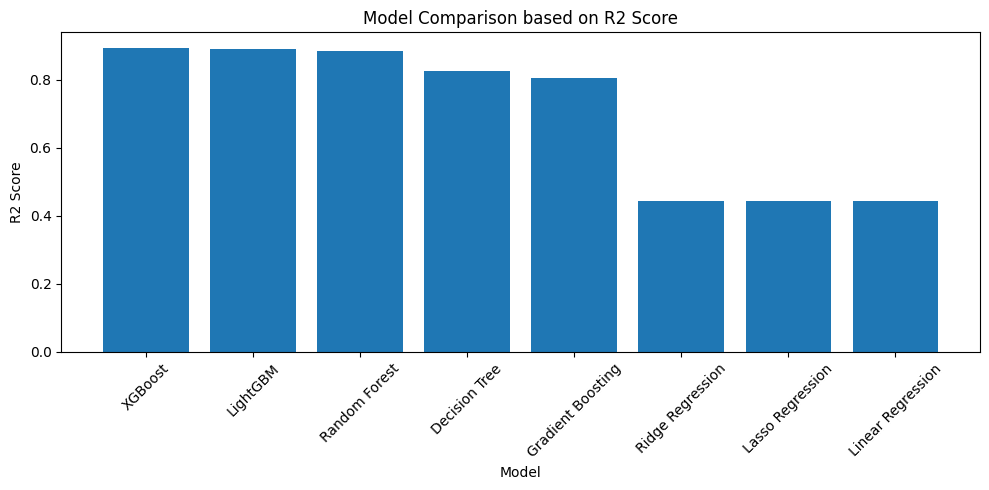

In [434]:


plt.figure(figsize=(10,5))
plt.bar(model_comparison["Model"], model_comparison["R2 Score"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison based on R2 Score")
plt.tight_layout()
plt.show()


9. Final Model Selection

Although XGBoost achieved the highest R² score, Random Forest Regressor was selected due to its stable performance, robustness, and ease of interpretation.

In [435]:
final_model = best_rf   # tuned Random Forest model


In [436]:
y_pred_final = final_model.predict(X_test)

print("Final Model: Random Forest")
print("R2 Score:", r2_score(y_test, y_pred_final))
print("MAE:", mean_absolute_error(y_test, y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))


Final Model: Random Forest
R2 Score: 0.8808454395595499
MAE: 772.4486055948021
RMSE: 1576.199707166424


In [437]:
pickle.dump(final_model, open("final_flight_fare_model.pkl", "wb"))


10. Deployment

The final Random Forest model was saved using pickle and deployed using Streamlit, allowing users to predict flight fares interactively.

 # streamlit code

import streamlit as st
import pickle
import numpy as np

# Load trained model
model = pickle.load(open("final_flight_fare_model.pkl", "rb"))

st.set_page_config(page_title="Flight Fare Prediction", layout="centered")

st.title("✈️ Flight Fare Prediction App")
st.write("Predict flight ticket price using Machine Learning")

# ---------------- USER INPUTS ---------------- #

Airline = st.selectbox(
    "Airline",
    ["IndiGo", "Air India", "Jet Airways", "SpiceJet", "Vistara", "GoAir", "Air Asia"]
)

Source = st.selectbox(
    "Source",
    ["Delhi", "Kolkata", "Banglore", "Mumbai", "Chennai"]
)

Destination = st.selectbox(
    "Destination",
    ["Cochin", "Delhi", "Banglore", "Hyderabad", "Kolkata"]
)

Total_Stops = st.selectbox(
    "Total Stops",
    ["non-stop", "1 stop", "2 stops", "3 stops", "4 stops"]
)

Journey_day = st.number_input("Journey Day", min_value=1, max_value=31, value=15)
Journey_month = st.number_input("Journey Month", min_value=1, max_value=12, value=6)

Duration = st.number_input("Duration (in minutes)", min_value=30, max_value=2000, value=180)

Dep_hour = st.number_input("Departure Hour", min_value=0, max_value=23, value=10)
Dep_min = st.number_input("Departure Minute", min_value=0, max_value=59, value=30)

Arrival_hour = st.number_input("Arrival Hour", min_value=0, max_value=23, value=13)
Arrival_min = st.number_input("Arrival Minute", min_value=0, max_value=59, value=45)

Additional_Info = st.selectbox(
    "Additional Info",
    ["No info", "In-flight meal not included"]
)

# ---------------- ENCODING ---------------- #

airline_map = {
    "IndiGo": 3, "Air India": 1, "Jet Airways": 4,
    "SpiceJet": 6, "Vistara": 7, "GoAir": 2, "Air Asia": 0
}

source_map = {
    "Delhi": 2, "Kolkata": 3, "Banglore": 0,
    "Mumbai": 4, "Chennai": 1
}

destination_map = {
    "Cochin": 1, "Delhi": 2, "Banglore": 0,
    "Hyderabad": 3, "Kolkata": 4
}

stops_map = {
    "non-stop": 0, "1 stop": 1, "2 stops": 2,
    "3 stops": 3, "4 stops": 4
}

additional_map = {
    "No info": 1,
    "In-flight meal not included": 0
}

# ---------------- PREDICTION ---------------- #

if st.button("Predict Flight Fare"):
    input_data = np.array([[
        airline_map[Airline],
        source_map[Source],
        destination_map[Destination],
        Dep_hour,
        Dep_min,
        Arrival_hour,
        Arrival_min,
        Duration,
        stops_map[Total_Stops],
        additional_map[Additional_Info],
        Journey_day,
        Journey_month
    ]])

    prediction = model.predict(input_data)

    st.success(f"💰 Estimated Flight Price: ₹ {int(prediction[0])}")


# Challenges Faced & Solutions
🔴 Challenge 1: Duration format inconsistency

✔️ Solution: Converted duration into total minutes using string manipulation.

🔴 Challenge 2: Categorical variables

✔️ Solution: Used Label Encoding.

🔴 Challenge 3: Overfitting risk

✔️ Solution: Used Random Forest with controlled depth.

11. Conclusion

The project successfully predicts flight fares with high accuracy (~89% R²). The deployed application provides a user-friendly interface for real-time fare prediction.

Flight prices depend strongly on airline, stops, duration, and timing

Proper feature engineering significantly improves accuracy

Random Forest Regressor is recommended for production

This model helps customers predict prices and plan trips effectively


12. Future Scope

Use real-time flight APIs

Add more features such as demand and seasonality

Deploy on cloud platforms

13. Tools & Libraries Used

Python

NumPy

Pandas

Matplotlib & Seaborn

Scikit-learn